## Библиотеки и константы


In [1]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import random
import scipy.stats as stats
import pylab
import struct
import json
import os
from IPython.display import clear_output
from math import factorial
from collections import defaultdict
from itertools import product, combinations, permutations
import inspect
import time

%matplotlib inline

In [2]:
TOTAL_COUNT = 1_000_000
BATCH_SIZE = 10_000

ARTIFACT_FORMAT = "<BBiBBiBBiBBi"
ARTIFACT_SIZE = struct.calcsize(ARTIFACT_FORMAT)

### Базовые значения

In [3]:
stats_map = {
    "HP%": 0,
    "HP": 1, 
    "ATK%": 2,
    "ATK": 3,
    "DEF%": 4,
    "DEF": 5,
    "EM": 6, # Elemental mastery
    "ER": 7, # Energy recharge
    "CRIT_RATE": 8, # Crit Rate
    "CRIT_DMG": 9, # Crit Damage
    "PHYS_DMG": 10,
    "PYRO_DMG": 11,
    "HYDRO_DMG": 12,
    "ANEMO_DMG": 13,
    "ELECTRO_DMG": 14,
    "DENDRO_DMG": 15,
    "CRYO_DMG": 16,
    "GEO_DMG": 17,
    "HEAL_BONUS": 18,
    "None": 100,
}

stat_names = [""] * (max(stats_map.values()) + 1)
for name, stat_id in stats_map.items():
    if stat_id >= 0:
        stat_names[stat_id] = name

main_stat_values_map = {
    stats_map["HP%"]: 4660,
    stats_map["HP"]: 478000, 
    stats_map["ATK%"]: 4660,
    stats_map["ATK"]: 3110,
    stats_map["DEF%"]: 5830,
    stats_map["EM"]: 18700,
    stats_map["ER"]: 5180,
    stats_map["CRIT_RATE"]: 3110,
    stats_map["CRIT_DMG"]: 6220,
    stats_map["PYRO_DMG"]: 4660, # same for all elements
    stats_map["PHYS_DMG"]: 5830,
    stats_map["HEAL_BONUS"]: 3590
}

base_sub_stats_choices = [
    stats_map["HP%"],
    stats_map["HP"], 
    stats_map["ATK%"],
    stats_map["ATK"],
    stats_map["DEF%"],
    stats_map["DEF"],
    stats_map["EM"],
    stats_map["ER"],
    stats_map["CRIT_RATE"],
    stats_map["CRIT_DMG"]
]

# 100%, 90%, 80%, 70%
sub_stats_values_map = {
    stats_map["HP%"]: [408, 466, 525, 583],
    stats_map["HP"]: [20913, 23900, 26988, 29975], 
    stats_map["ATK%"]: [408, 466, 525, 583],
    stats_map["ATK"]: [1362, 1556, 1751, 1945],
    stats_map["DEF%"]: [510, 583, 656, 729],
    stats_map["DEF"]: [1620, 1852, 2083, 2315],
    stats_map["EM"]: [1632, 1865, 2098, 2331],
    stats_map["ER"]: [453, 518, 583, 648],
    stats_map["CRIT_RATE"]: [272, 311, 350, 389],
    stats_map["CRIT_DMG"]: [544, 622, 699, 777]
}

sub_stats_weights_map = {
    stats_map["HP%"]: 4,
    stats_map["HP"]: 6,
    stats_map["ATK%"]: 4,
    stats_map["ATK"]: 6,
    stats_map["DEF%"]: 4,
    stats_map["DEF"]: 6,
    stats_map["EM"]: 4,
    stats_map["ER"]: 4,
    stats_map["CRIT_RATE"]: 3,
    stats_map["CRIT_DMG"]: 3
}

file_names = {'HP%', 'HP', 'ATK%', 'ATK', 'DEF%', 'EM', 'ER', "CRIT_RATE", "CRIT_DMG"}
sub_stat_max_values = np.array([sub_stats_values_map[stat][-1] for stat in base_sub_stats_choices])

In [4]:
slot_1_pop = [stats_map["HP"]]
slot_1_prob = [1]

slot_2_pop = [stats_map["ATK"]]
slot_2_prob = [1]

slot_3_pop = [
    stats_map["HP%"],
    stats_map["ATK%"],
    stats_map["DEF%"],
    stats_map["ER"],
    stats_map["EM"]
]
slot_3_prob = [0.8/3, 0.8/3, 0.8/3, 0.1, 0.1]

slot_4_pop = [
    stats_map["HP%"],
    stats_map["ATK%"],
    stats_map["DEF%"],
    stats_map["PHYS_DMG"],
    stats_map["PYRO_DMG"],
    stats_map["HYDRO_DMG"],
    stats_map["ANEMO_DMG"],
    stats_map["ELECTRO_DMG"],
    stats_map["DENDRO_DMG"],
    stats_map["CRYO_DMG"],
    stats_map["GEO_DMG"],
    stats_map["EM"]
]
slot_4_prob = [0.1925, 0.1925, 0.19, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.025]

slot_5_pop = [
    stats_map["HP%"],
    stats_map["ATK%"],
    stats_map["DEF%"],
    stats_map["CRIT_RATE"],
    stats_map["CRIT_DMG"],
    stats_map["EM"],
    stats_map["HEAL_BONUS"]
]
slot_5_prob = [0.22, 0.22, 0.22, 0.1, 0.1, 0.04, 0.1]

slots = ["FLOWER", "PLUME", "SANDS", "GOBLET", "CIRCLET"]

slots_prob = {
    "FLOWER": (slot_1_pop, slot_1_prob),
    "PLUME": (slot_2_pop, slot_2_prob),
    "SANDS": (slot_3_pop, slot_3_prob),
    "GOBLET": (slot_4_pop, slot_4_prob),
    "CIRCLET": (slot_5_pop, slot_5_prob),
}

### Сохранение/Загрузка

In [5]:
def load_characters(uid):
    with open(f"characters/{uid}_parsed.json", "r", encoding="utf-8") as file:
        characters = json.load(file)

    return characters

def save_characters(characters, uid):
    characters = dict(sorted(characters.items()))
    with open(f"characters/{uid}_parsed.json", "w", encoding="utf-8") as file:
        json.dump(
            characters,
            file,
            ensure_ascii=False,
            indent=4
        )

### Просчет рейтинга

In [6]:
def get_2_best_stat(main_stat, profit_order):
    best_stats = [
        stat for stat in profit_order
        if stat != main_stat
    ][:2]

    return best_stats[0], best_stats[1]

def evaluate_artifact(slot, artifact, char_profit, profit_order):
    file_name = f"artifacts/artifacts_{TOTAL_COUNT}_"
    if artifact["main_stat"] in file_names:
       file_name += artifact["main_stat"]
    else:
        file_name += "None"
    file_name += ".bin"
    
    main_stat = stats_map[artifact["main_stat"]]
    selected_stat_1, selected_stat_2 = get_2_best_stat(main_stat, profit_order)
    selected_stat_1_coef = 1 / sub_stat_max_values[selected_stat_1]
    selected_stat_2_coef = 1 / sub_stat_max_values[selected_stat_2]
    
    char_artifact_profit = np.dot(artifact["substats"], char_profit)
    count_better = 0
    count_craft = 0
    count_craft_better = 0
    with open(file_name, "rb") as file:
        while data := file.read(ARTIFACT_SIZE):

            gen_artifact = struct.unpack(ARTIFACT_FORMAT, data)
            gen_profit = np.dot(gen_artifact, char_profit)
            if gen_profit > char_artifact_profit:
                count_better += 1
                
            if (
                gen_artifact[selected_stat_1] > 0
                and gen_artifact[selected_stat_2] > 0
                and (
                    gen_artifact[selected_stat_1] * selected_stat_1_coef
                    + gen_artifact[selected_stat_2] * selected_stat_2_coef
                    >= 2.79
                )
            ):
                count_craft += 1

                if gen_profit > char_artifact_profit:
                    count_craft_better += 1
                
    main_stat_pop, main_stat_prob = slots_prob[slot]
    idx = main_stat_pop.index(main_stat)
    
    count_better /= TOTAL_COUNT
    artifact["upgrade_chance"]["craft"] = round(count_craft_better / count_craft if count_craft else 0, 6)
    artifact["score"] = round((1 - count_better * main_stat_prob[idx]) * 100 , 4)
    
def evaluate_artifact_new(slot, artifact, char_profit, profit_order):
    file_name = f"artifacts/artifacts_{TOTAL_COUNT}_"
    if artifact["main_stat"] in file_names:
       file_name += artifact["main_stat"]
    else:
        file_name += "None"
    file_name += ".bin"
    
    main_stat = stats_map[artifact["main_stat"]]
    selected_stat_1, selected_stat_2 = get_2_best_stat(main_stat, profit_order)

    char_artifact_profit = np.dot(artifact["substats"], char_profit)
    count_better = 0
    count_craft = 0
    count_craft_better = 0

    with open(file_name, "rb") as file:
        while data := file.read(ARTIFACT_SIZE):
            (
                stat_id_1, roll_count_1, value_1,
                stat_id_2, roll_count_2, value_2,
                stat_id_3, roll_count_3, value_3,
                stat_id_4, roll_count_4, value_4,
            ) = struct.unpack(ARTIFACT_FORMAT, data)
            
            is_better = (
                value_1 * char_profit[stat_id_1]
                + value_2 * char_profit[stat_id_2]
                + value_3 * char_profit[stat_id_3]
                + value_4 * char_profit[stat_id_4]
            ) > char_artifact_profit
            
            
            if is_better:
                count_better += 1
            
            # расчет шанс улучшения среди артефактов, подходящих под условие крафта
            selected_roll_count_1 = 0
            selected_roll_count_2 = 0
                
            if selected_stat_1 == stat_id_1:
                selected_roll_count_1 = roll_count_1
            elif selected_stat_1 == stat_id_2:
                selected_roll_count_1 = roll_count_2
            elif selected_stat_1 == stat_id_3:
                selected_roll_count_1 = roll_count_3
            elif selected_stat_1 == stat_id_4:
                selected_roll_count_1 = roll_count_4

            if selected_stat_2 == stat_id_1:
                selected_roll_count_2 = roll_count_1
            elif selected_stat_2 == stat_id_2:
                selected_roll_count_2 = roll_count_2
            elif selected_stat_2 == stat_id_3:
                selected_roll_count_2 = roll_count_3
            elif selected_stat_2 == stat_id_4:
                selected_roll_count_2 = roll_count_4
                
            if (
                selected_roll_count_1 != 0
                and selected_roll_count_2 != 0
                and selected_roll_count_1 + selected_roll_count_2 >= 4
            ):
                count_craft += 1

                if is_better:
                    count_craft_better += 1
                
    main_stat_pop, main_stat_prob = slots_prob[slot]
    idx = main_stat_pop.index(main_stat)
    
    count_better /= TOTAL_COUNT
    artifact["upgrade_chance"]["craft"] = round(count_craft_better / count_craft if count_craft else 0, 6)
    artifact["score"] = round((1 - count_better * main_stat_prob[idx]) * 100 , 4)

def evaluate_character(character, character_profit, profit_order):
    score = 0
    for slot in slots:
        artifact = character["artifacts"][slot]
        evaluate_artifact_new(slot, artifact, character_profit, profit_order)
        score += artifact["score"]
        
    character["score"] = round(score, 4)

def evaluate_characters(characters):
    characters_to_evaluate = [
        character
        for character in characters.values()
        if character["score"] <= 1000
    ]

    total = len(characters_to_evaluate)
    start_time = time.perf_counter()

    for i, character in enumerate(characters_to_evaluate, start=1):
        char_profit = np.array(character["sub_stat_profit"])
        profit_order = np.argsort(char_profit)[::-1]
        char_profit /= sub_stat_max_values
        evaluate_character(character, char_profit, profit_order)

        elapsed = time.perf_counter() - start_time
        print(
            f"\rProgress: {i}/{total} "
            f"({i / total * 100:.1f}%) | "
            f"Time: {elapsed:.1f}s",
            end="",
            flush=True
        )

    print()
    return characters_to_evaluate
        

In [7]:
characters = load_characters(723396058)

In [18]:
characters_to_update = evaluate_characters(characters)

Progress: 32/32 (100.0%) | Time: 212.6s


In [15]:
characters_to_update = evaluate_characters(characters)

Progress: 32/32 (100.0%) | Time: 322.3s


In [25]:
evaluate_characters_rerol_chance(characters_to_update)

Progress: 32/32 (100.0%) | Time: 1.7s


In [27]:
save_characters(characters, 723396058)

In [ ]:
Progress: 32/32 (100.0%) | Time: 312.4s

### тесты с уменьшением выборки

In [19]:
def compare_scores(results, reference):
    reference = list(reference)

    print(
        f"{'Sample':>12} | "
        f"{'Char avg':>10} "
        f"{'Char max':>10} "
        f"{'Char abs':>10} | "
        f"{'Art avg':>10} "
        f"{'Art max':>10} "
        f"{'Art abs':>10} | "
        f"{'Craft avg':>10} "
        f"{'Craft max':>10} "
        f"{'Craft abs':>10}"
    )
    print("-" * 126)

    for sample_size, characters in sorted(results.items()):
        characters = list(characters)

        character_diffs = []
        artifact_diffs = []
        craft_diffs = []

        for character, ref_character in zip(characters, reference):
            character_diffs.append(
                character["score"] - ref_character["score"]
            )

            for slot in slots:
                artifact = character["artifacts"][slot]
                ref_artifact = ref_character["artifacts"][slot]

                artifact_diffs.append(
                    artifact["score"] - ref_artifact["score"]
                )

                craft_diffs.append(
                    (
                        artifact["upgrade_chance"]["craft"]
                        - ref_artifact["upgrade_chance"]["craft"]
                    ) * 100
                )

        char_avg = sum(character_diffs) / len(character_diffs)
        char_abs = sum(abs(diff) for diff in character_diffs) / len(character_diffs)
        char_max = max(character_diffs, key=abs)

        art_avg = sum(artifact_diffs) / len(artifact_diffs)
        art_abs = sum(abs(diff) for diff in artifact_diffs) / len(artifact_diffs)
        art_max = max(artifact_diffs, key=abs)

        craft_avg = sum(craft_diffs) / len(craft_diffs)
        craft_abs = sum(abs(diff) for diff in craft_diffs) / len(craft_diffs)
        craft_max = max(craft_diffs, key=abs)

        print(
            f"{sample_size:>12,} | "
            f"{char_avg:>+10.4f} "
            f"{char_max:>+10.4f} "
            f"{char_abs:>10.4f} | "
            f"{art_avg:>+10.4f} "
            f"{art_max:>+10.4f} "
            f"{art_abs:>10.4f} | "
            f"{craft_avg:>+10.3f} "
            f"{craft_max:>+10.3f} "
            f"{craft_abs:>10.3f}"
        )

In [12]:
TOTAL_COUNT = 50_000
characters_test = load_characters(723396058)
characters_50k = evaluate_characters(characters_test)

Progress: 32/32 (100.0%) | Time: 11.0s


In [13]:
TOTAL_COUNT = 100_000
characters_test = load_characters(723396058)
characters_100k = evaluate_characters(characters_test)

Progress: 32/32 (100.0%) | Time: 21.8s


In [14]:
TOTAL_COUNT = 250_000
characters_test = load_characters(723396058)
characters_250k = evaluate_characters(characters_test)

Progress: 32/32 (100.0%) | Time: 55.0s


In [15]:
TOTAL_COUNT = 500_000
characters_test = load_characters(723396058)
characters_500k = evaluate_characters(characters_test)

Progress: 32/32 (100.0%) | Time: 105.3s


In [20]:
results = {
    50_000: characters_50k,
    100_000: characters_100k,
    250_000: characters_250k,
    500_000: characters_500k,
    1_000_000: characters.values()
}

compare_scores(results, characters.values())

      Sample |   Char avg   Char max   Char abs |    Art avg    Art max    Art abs |  Craft avg  Craft max  Craft abs
------------------------------------------------------------------------------------------------------------------------------
      50,000 |    -0.0400    -0.3148     0.0850 |    -0.0080    -0.2020     0.0244 |     -0.017     +1.921      0.491
     100,000 |    +0.0190    +0.2494     0.0660 |    +0.0038    +0.2733     0.0246 |     +0.095     +1.676      0.427
     250,000 |    +0.0085    +0.1223     0.0349 |    +0.0017    +0.1125     0.0113 |     +0.046     +0.953      0.217
     500,000 |    -0.0341    -0.0930     0.0350 |    -0.0068    -0.0832     0.0096 |     +0.045     +0.597      0.157
   1,000,000 |    +0.0000    +0.0000     0.0000 |    +0.0000    +0.0000     0.0000 |     +0.000     +0.000      0.000


### Функции отрисовки

In [8]:
def plot_characters(characters):
    sorted_characters = sorted(
        characters.items(),
        key=lambda x: x[1]["score"],
        reverse=True
    )

    names = [name for name, char in sorted_characters]
    scores = [
        character["score"]
        for _, character in sorted_characters
    ]

    plt.figure(figsize=(12, len(names) / 3.5))

    bars = plt.barh(names, scores)

    for bar, score in zip(bars, scores):
        plt.text(
            score + 2,
            bar.get_y() + bar.get_height() / 2,
            f"{score:.1f}",
            va="center"
        )

    plt.xlim(0, 530)
    plt.xlabel("Суммарная оценка артефактов")
    plt.title("Оценка персонажей")

    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()
    
def draw_artifact_scores(characters):
    artifact_y_min = min(
        character["artifacts"][slot]["score"]
        for character in characters.values()
        for slot in slots
        if slot in character["artifacts"]
    )

    artifact_y_min = max(0, artifact_y_min * 0.9)

    sorted_characters = sorted(
        characters.items(),
        key=lambda x: x[1]["score"]
    )

    for character_name, character in sorted_characters:
        if "score" not in character:
            continue
        character_score = character["score"]

        artifact_scores = [
            character["artifacts"][slot]["score"]
            for slot in slots
        ]

        plt.figure(figsize=(9, 5))

        bars = plt.bar(
            slots,
            artifact_scores
        )

        plt.ylim(artifact_y_min, 105)

        plt.xlabel("Artifact")
        plt.ylabel("Score")
        plt.title(f"{character_name} artifact scores, sum: {character_score:.1f}")

        for bar, score in zip(bars, artifact_scores):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                score + 0.2,
                f"{score:.2f}",
                ha="center",
                va="bottom"
            )

        plt.tight_layout()
        plt.show()
        
        
def print_artifacts_by_character(characters):
    print("ARTIFACTS")
    print(
        f"{'Character':15} {'Slot':10} {'Score':>8} | "
        f"{'Reroll chance':^32} | {'Craft':>10}"
    )
    print(
        f"{'':15} {'':10} {'':8} | "
        f"{'2 guarant':>10} {'3 guarant':>10} {'4 guarant':>10} | {'':>10}"
    )
    print("-" * 95)

    sorted_characters = sorted(
        characters.items(),
        key=lambda x: x[1]["score"]
    )

    word_set = "SET"
    
    for character_name, character in sorted_characters:
        print(
            f"{character_name:15} {'TOTAL':10} "
            f"{character['score']:8.2f} | "
            f"{'':>10} {'':>10} {'':>10} | "
            f"{'':>10}"
        )
        for slot in slots:
            artifact = character["artifacts"][slot]
            upgrade_chance = artifact["upgrade_chance"]

            print(
                f"{character_name:15} {slot:10} "
                f"{artifact['score']:8.2f} | "
                f"{upgrade_chance['2_guarant'] * 100:9.2f}% "
                f"{upgrade_chance['3_guarant'] * 100:9.2f}% "
                f"{upgrade_chance['4_guarant'] * 100:9.2f}% | "
                f"{upgrade_chance['craft'] * 100:9.2f}%"
            )
        
        print("-" * 95)
        
def print_sorted_artifacts(characters):
    artifacts = []

    for character_name, character in characters.items():
        for slot in slots:
            artifact = character["artifacts"][slot]

            artifacts.append((
                character_name,
                slot,
                artifact
            ))

    artifacts.sort(
        key=lambda x: x[2]["score"]
    )

    print("ARTIFACTS")
    print(
        f"{'Character':15} {'Slot':10} {'Score':>8} | "
        f"{'Reroll chance':^32} | {'Craft':>10}"
    )
    print(
        f"{'':15} {'':10} {'':8} | "
        f"{'2 guarant':>10} {'3 guarant':>10} {'4 guarant':>10} | {'':>10}"
    )
    print("-" * 95)

    for character_name, slot, artifact in artifacts:
        upgrade_chance = artifact["upgrade_chance"]

        print(
            f"{character_name:15} {slot:10} "
            f"{artifact['score']:8.2f} | "
            f"{upgrade_chance['2_guarant'] * 100:9.2f}% "
            f"{upgrade_chance['3_guarant'] * 100:9.2f}% "
            f"{upgrade_chance['4_guarant'] * 100:9.2f}% | "
            f"{upgrade_chance['craft'] * 100:9.2f}%"
        )

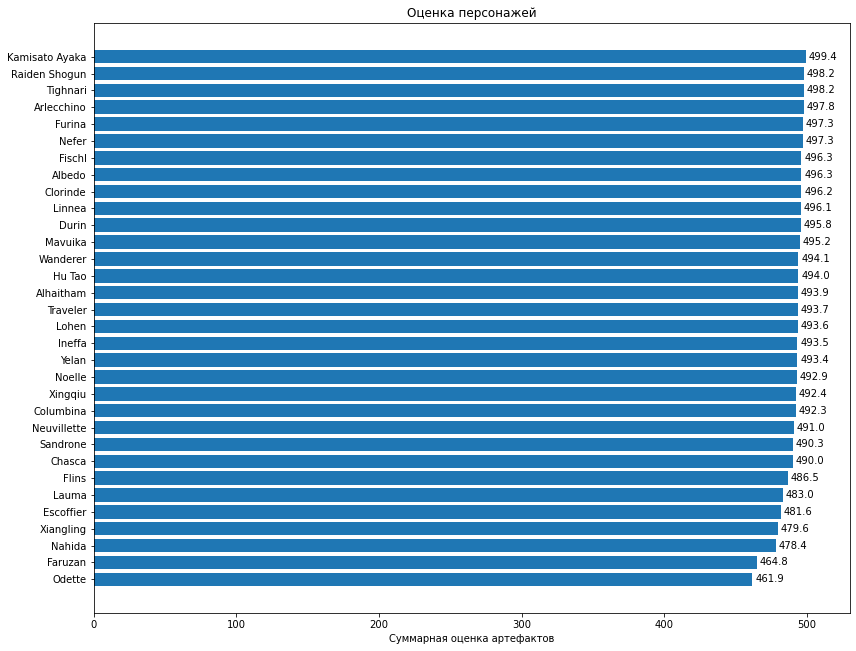

In [9]:
plot_characters(characters)

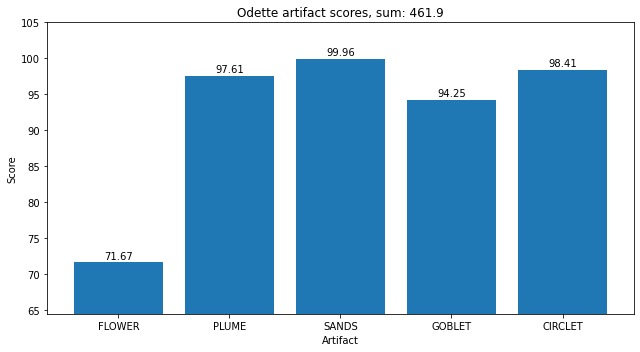

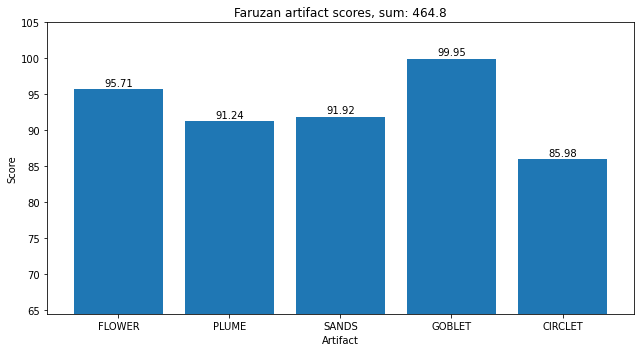

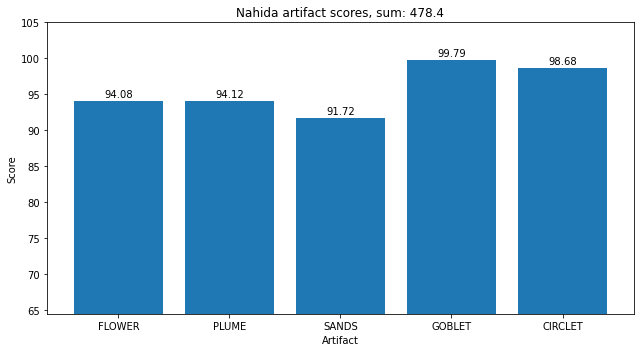

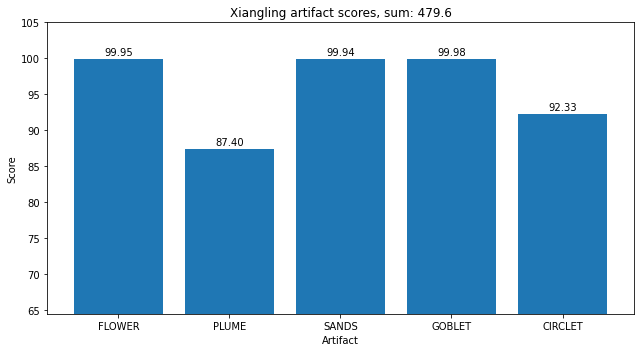

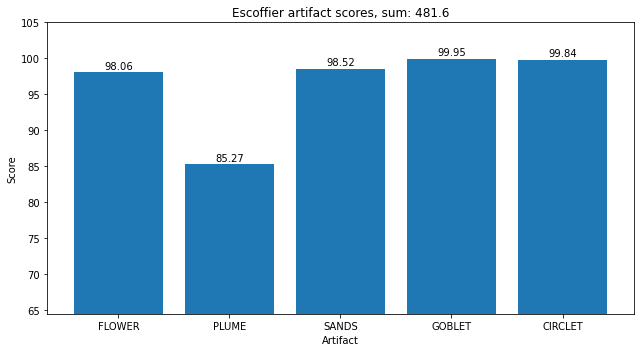

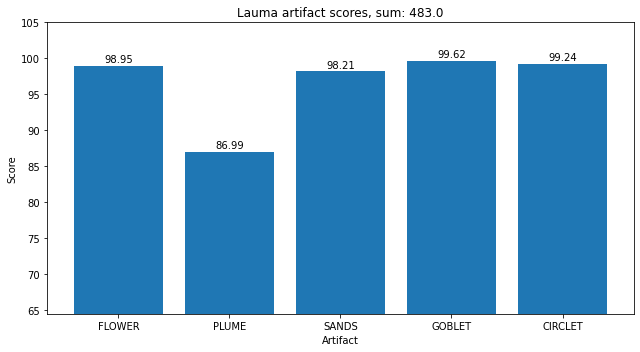

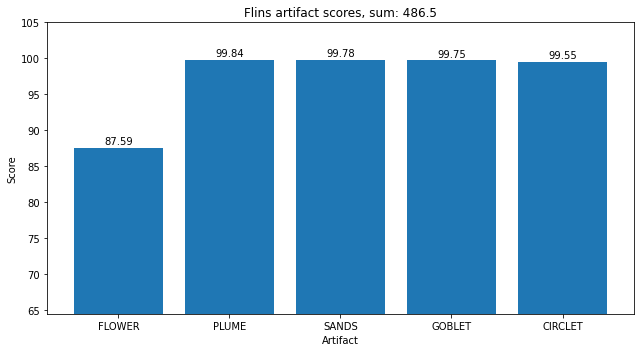

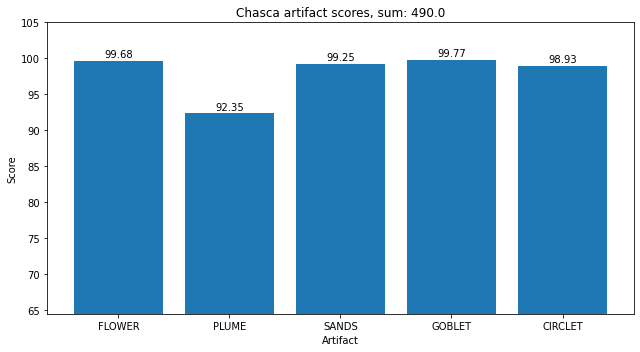

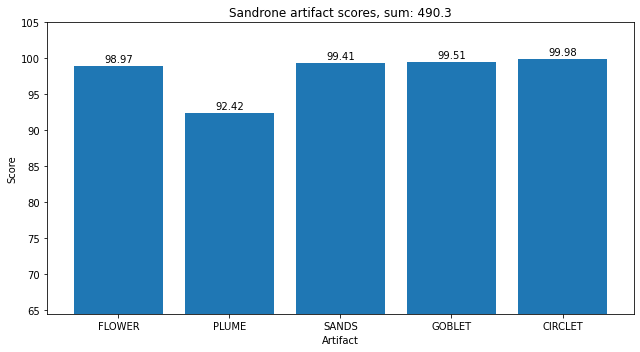

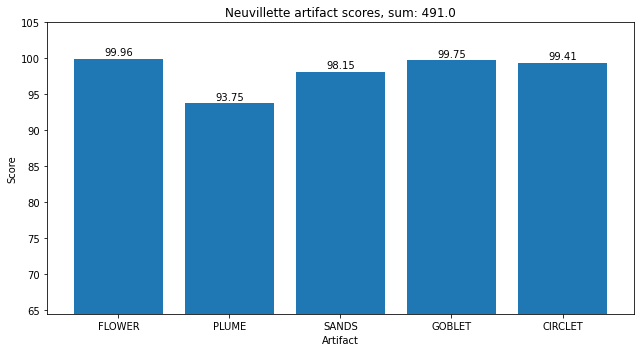

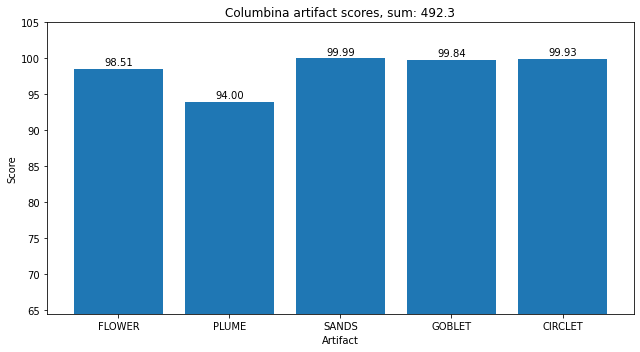

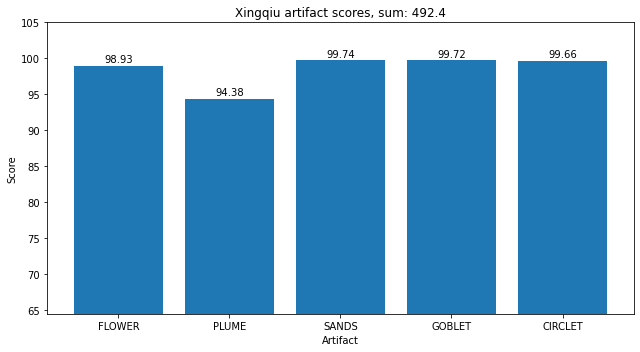

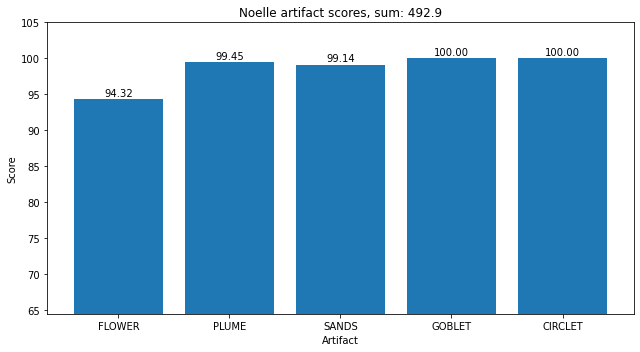

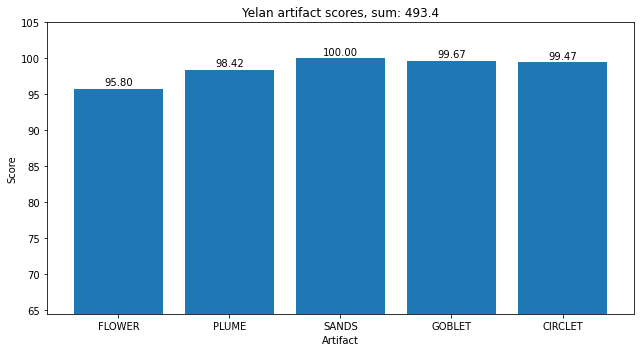

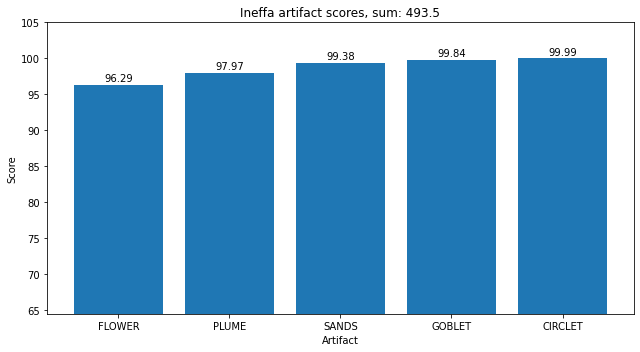

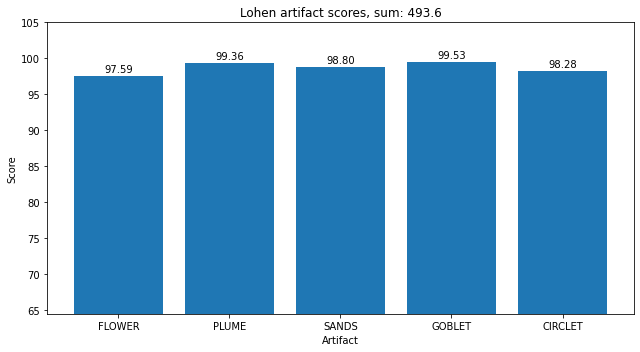

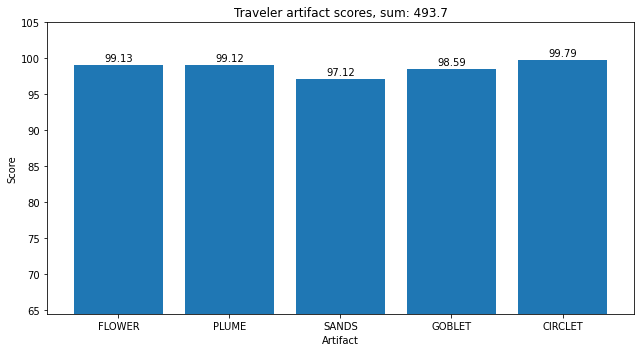

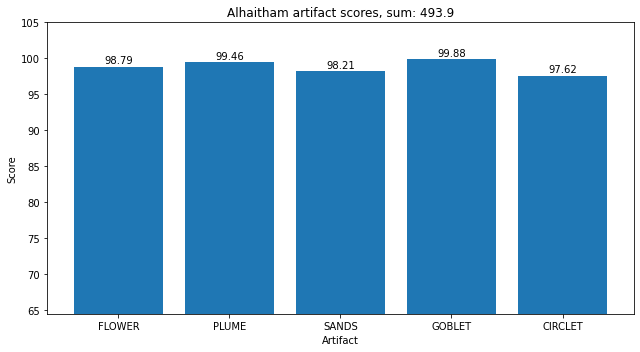

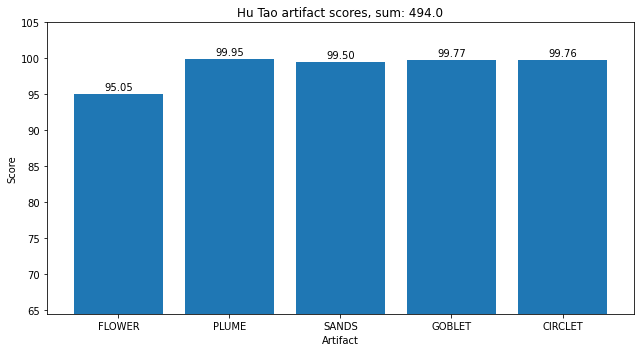

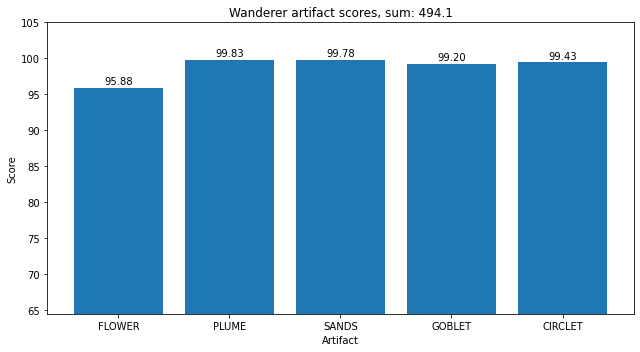

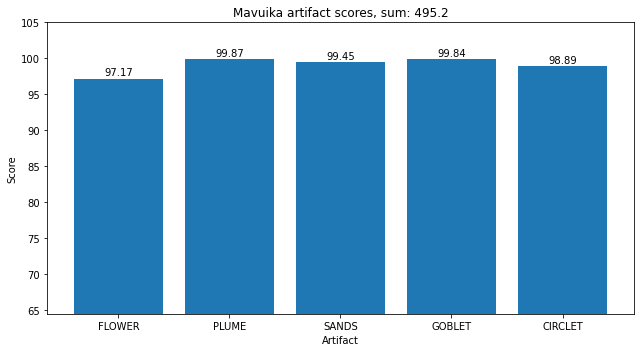

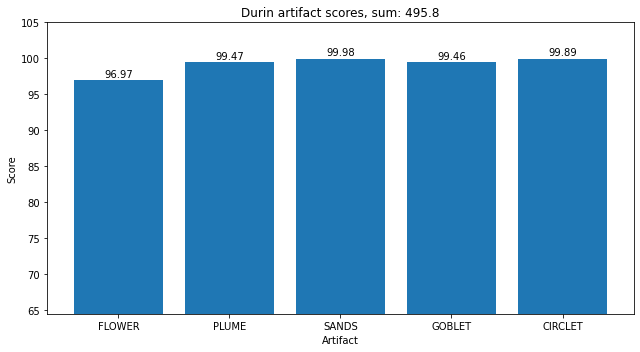

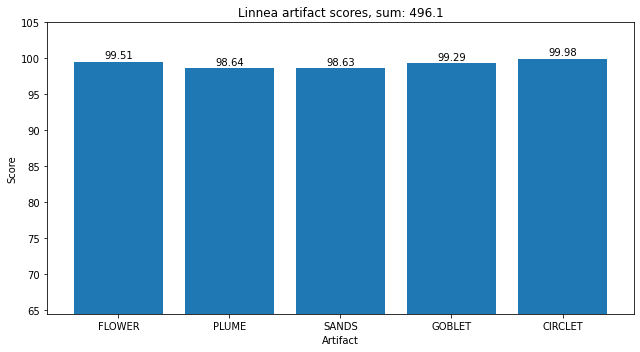

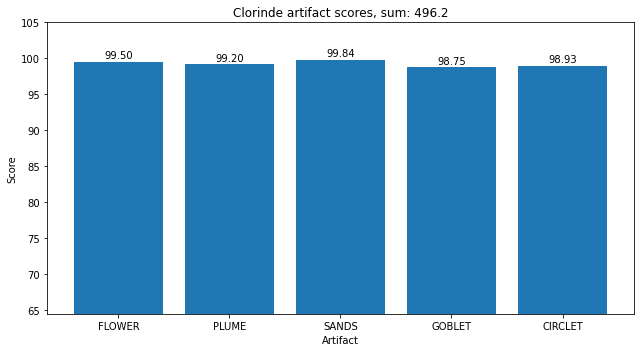

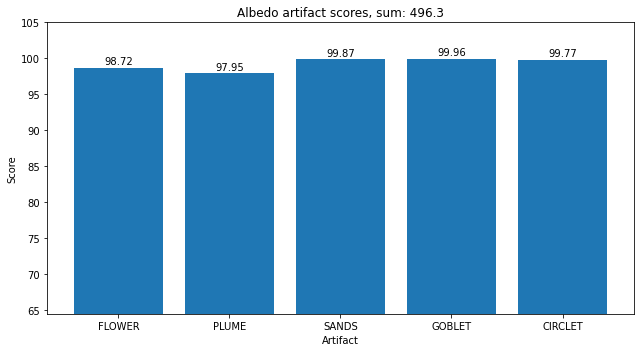

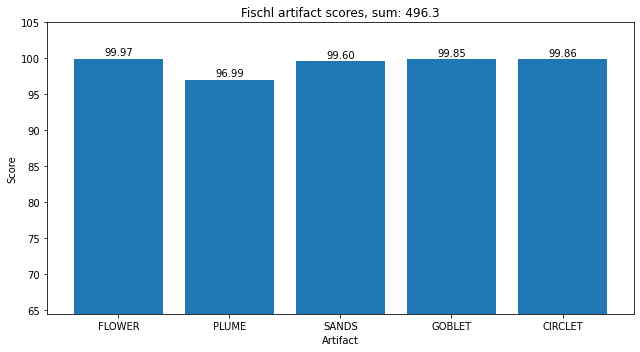

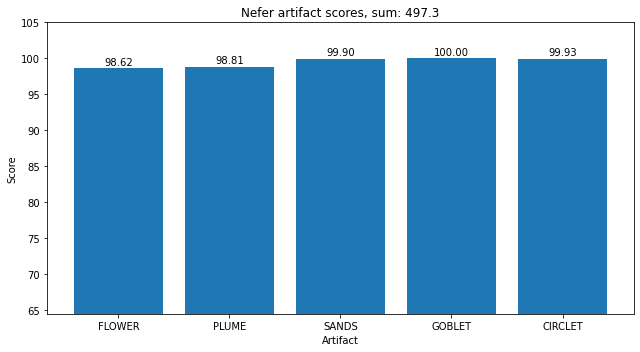

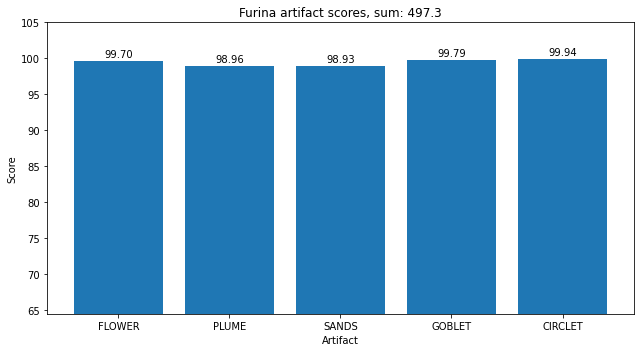

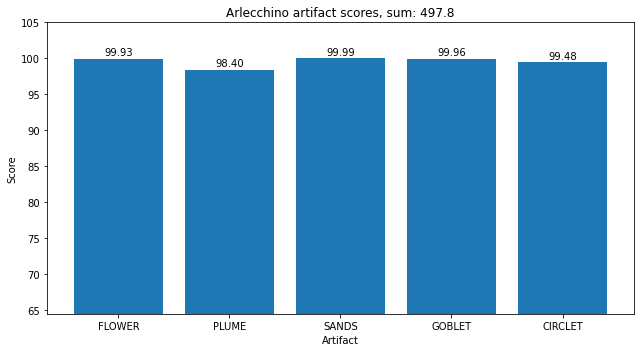

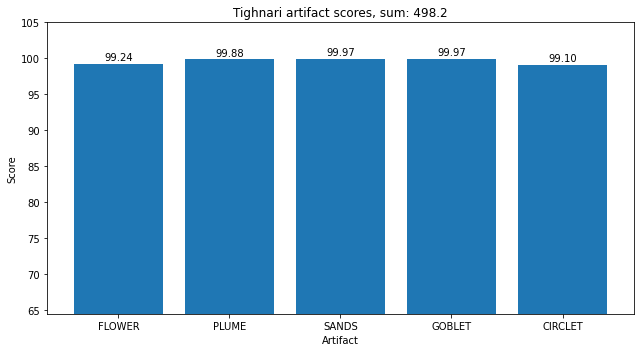

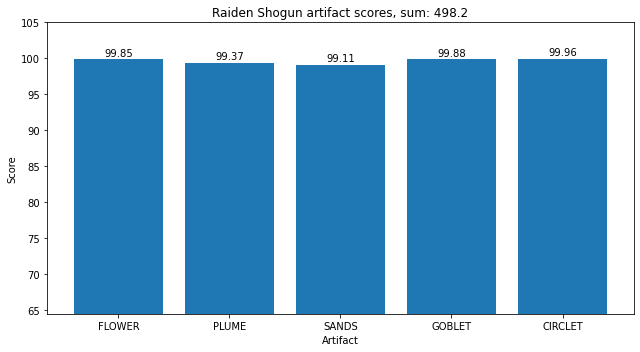

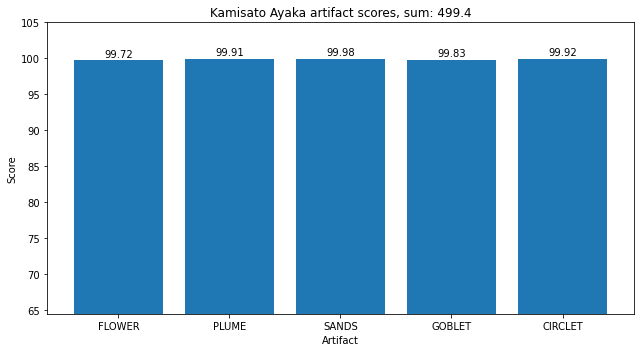

In [10]:
draw_artifact_scores(characters)

In [26]:
print_artifacts_by_character(characters)

ARTIFACTS
Character       Slot          Score |          Reroll chance           |      Craft
                                    |  2 guarant  3 guarant  4 guarant |           
-----------------------------------------------------------------------------------------------
Odette          TOTAL        461.88 |                                  |           
Odette          FLOWER        71.67 |     99.36%    100.00%    100.00% |     79.30%
Odette          PLUME         97.61 |     21.07%     32.71%     59.16% |     14.19%
Odette          SANDS         99.96 |     25.38%     34.38%     53.80% |      1.81%
Odette          GOBLET        94.25 |    100.00%    100.00%    100.00% |     98.96%
Odette          CIRCLET       98.41 |     44.96%     98.91%    100.00% |     73.90%
-----------------------------------------------------------------------------------------------
Faruzan         TOTAL        464.79 |                                  |           
Faruzan         FLOWER        95.71 |     

In [34]:
print_sorted_artifacts(characters)

ARTIFACTS
Character       Slot          Score |          Reroll chance           |      Craft
                                    |  2 guarant  3 guarant  4 guarant |           
-----------------------------------------------------------------------------------------------
Odette          FLOWER        71.68 |     99.36%    100.00%    100.00% |     77.75%
Escoffier       PLUME         85.28 |     52.27%    100.00%    100.00% |     73.93%
Faruzan         CIRCLET       86.01 |     81.25%     88.75%     93.75% |    100.00%
Lauma           PLUME         87.01 |     58.92%    100.00%    100.00% |     63.79%
Xiangling       PLUME         87.36 |     80.88%    100.00%    100.00% |     76.86%
Flins           FLOWER        87.61 |     94.65%    100.00%    100.00% |     57.07%
Faruzan         PLUME         91.26 |      3.55%      7.81%     23.44% |     65.35%
Nahida          SANDS         91.72 |     71.87%    100.00%    100.00% |    100.00%
Faruzan         SANDS         91.92 |    100.00%    10

### Расчет рерола сабстатов перьями

In [20]:
def get_roll_value_distribution(roll_values, roll_count):
    distribution = {0: 1.0}

    probability = 1 / len(roll_values)

    for _ in range(roll_count):
        new_distribution = defaultdict(float)

        for current_value, current_probability in distribution.items():
            for roll_value in roll_values:
                new_distribution[current_value + roll_value] += (
                    current_probability * probability
                )

        distribution = new_distribution

    return dict(distribution)


all_roll_value_distributions = {
    stat: {
        roll_count: get_roll_value_distribution(
            sub_stats_values_map[stat],
            roll_count
        )
        for roll_count in range(7)
    }
    for stat in base_sub_stats_choices
}

In [21]:
def get_roll_distributions(roll_count):
    result = []

    for r1 in range(roll_count + 1):
        for r2 in range(roll_count - r1 + 1):
            for r3 in range(roll_count - r1 - r2 + 1):
                r4 = roll_count - r1 - r2 - r3

                rolls = (r1, r2, r3, r4)

                combinations = (
                    factorial(roll_count)
                    // (
                        factorial(r1)
                        * factorial(r2)
                        * factorial(r3)
                        * factorial(r4)
                    )
                )

                probability = combinations / (4 ** roll_count)

                result.append((rolls, probability))

    return result

roll_distributions = {
    4: get_roll_distributions(4),
    5: get_roll_distributions(5)
}

In [22]:
def get_valid_roll_distributions(artifact, selected_stats):
    count_rolls = max(artifact["count_rolls"], 4)
    substats = list(artifact["first_rolls"].keys())

    selected_indexes = [
        substats.index(stat)
        for stat in selected_stats
    ]

    guaranteed_rolls = {
        2: [],
        3: [],
        4: []
    }
    
    roll_distribution = roll_distributions[count_rolls]

    for rolls, probability in roll_distribution:
        selected_rolls = sum(
            rolls[index]
            for index in selected_indexes
        )

        for guaranteed_count in guaranteed_rolls:
            if selected_rolls >= guaranteed_count:
                guaranteed_rolls[guaranteed_count].append((rolls, probability))

    # Нормализация каждого распределения отдельно
    for guaranteed_count, distributions in guaranteed_rolls.items():
        total_probability = sum(
            probability
            for _, probability in distributions
        )

        guaranteed_rolls[guaranteed_count] = [
            (rolls, probability / total_probability)
            for rolls, probability in distributions
        ]

    return guaranteed_rolls

In [23]:
def get_preferred_substats(substats, char_profit, count=2):
    return sorted(
        substats,
        key=lambda stat: char_profit[stats_map[stat]],
        reverse=True
    )[:count]

def evaluate_artifact_reroll_score(artifact, char_profit):
    substats = list(artifact["first_rolls"].keys())
    # Выбираем лучшие статы по ценности максимального ролла    
    selected_stats = get_preferred_substats(substats, char_profit)
    char_profit = char_profit / sub_stat_max_values

    # Ценность только старых дополнительных проков.
    # Первоначальные проки одинаковы до и после reroll.
    # Вычитаем ценность первоначальных проков.
    current_profit = np.dot(
        artifact["substats"],
        char_profit
    )
    for stat, first_roll in artifact["first_rolls"].items():
        current_profit -= first_roll * char_profit[stats_map[stat]]

    valid_distributions = get_valid_roll_distributions(artifact, selected_stats)

    result = {
        2: 0.0,
        3: 0.0,
        4: 0.0
    }

    for guaranteed_count, distributions in valid_distributions.items():
        for rolls_distribution, distribution_probability in distributions:

            stat_distributions = []

            for stat, stat_roll_count in zip(
                substats,
                rolls_distribution
            ):
                stat_index = stats_map[stat]

                value_distribution = all_roll_value_distributions[stat_index][stat_roll_count]

                stat_distributions.append(
                    value_distribution.items()
                )

            # Все комбинации итоговых значений четырёх сабстатов
            for combination in product(*stat_distributions):

                # combination:
                # (
                #   (CR_value, CR_probability),
                #   (CD_value, CD_probability),
                #   ...
                # )
                rerolled_profit = 0
                probability = distribution_probability

                for stat, (value, stat_probability) in zip(
                    substats,
                    combination
                ):
                    stat_index = stats_map[stat]

                    rerolled_profit += (
                        value * char_profit[stat_index]
                    )

                    probability *= stat_probability

                if rerolled_profit > current_profit:
                    result[guaranteed_count] += probability
                    
    artifact["upgrade_chance"]["2_guarant"] = result[2]
    artifact["upgrade_chance"]["3_guarant"] = result[3]
    artifact["upgrade_chance"]["4_guarant"] = result[4]


In [24]:
def evaluate_characters_rerol_chance(characters):
    
    total = len(characters)
    start_time = time.perf_counter()
    
    for i, character in enumerate(characters, start=1):
        char_profit = np.array(character["sub_stat_profit"])
        for slot in slots:
            evaluate_artifact_reroll_score(character["artifacts"][slot], char_profit)
            
        elapsed = time.perf_counter() - start_time
        print(
            f"\rProgress: {i}/{total} "
            f"({i / total * 100:.1f}%) | "
            f"Time: {elapsed:.1f}s",
            end="",
            flush=True
        )

    print()

### Расчет улучшения бутылками (упрощенный)

In [24]:
def evaluate_characters_craft_chance_simple(characters):
    
    total = len(characters)
    start_time = time.perf_counter()
    
    for i, character in enumerate(characters, start=1):
        for slot in slots:
            artifact = character["artifacts"][slot]
            main_stat = stats_map[artifact["main_stat"]]
            score = artifact["score"]
            
            main_stat_pop, main_stat_prob = slots_prob[slot]
            idx = main_stat_pop.index(main_stat)

            better_probability = (1 - score / 100) / main_stat_prob[idx]

            artifact["upgrade_chance"]["craft"] = round(
                min(better_probability / 0.11875, 1.0),
                6
            )
            
        elapsed = time.perf_counter() - start_time
        print(
            f"\rProgress: {i}/{total} "
            f"({i / total * 100:.1f}%) | "
            f"Time: {elapsed:.1f}s",
            end="",
            flush=True
        )

    print()

### Расчет улучшения бутылками

In [25]:
def get_bottle_substat_select_distributions(
    main_stat,
    selected_stats_idx
):
    # Сабстат не может совпадать с main stat
    available_stats = [
        stat
        for stat in base_sub_stats_choices
        if stat != main_stat
    ]

    # Все возможные пары двух дополнительных статов
    other_stats = [
        stat
        for stat in available_stats
        if stat not in selected_stats_idx
    ]

    pair_probabilities = {}

    for pair in combinations(other_stats, 2):
        four_stats = selected_stats_idx + list(pair)
        probability = 0.0

        # Один и тот же набор из 4 статов можно получить
        # в 4! = 24 различных порядках
        for order in permutations(four_stats):
            remaining_weight = sum(
                sub_stats_weights_map[stat]
                for stat in available_stats
            )

            order_probability = 1.0

            for stat in order:
                weight = sub_stats_weights_map[stat]

                order_probability *= (
                    weight / remaining_weight
                )

                remaining_weight -= weight

            probability += order_probability

        pair_probabilities[pair] = probability

    # Мы рассматриваем только артефакты,
    # где присутствуют selected_stats.
    # Поэтому нормализуем вероятности.
    total_probability = sum(
        pair_probabilities.values()
    )

    for pair in pair_probabilities:
        pair_probabilities[pair] /= total_probability

    return pair_probabilities

In [ ]:
def get_valid_bottle_roll_distributions(roll_count):
    result = []

    for rolls, probability in get_roll_distributions(roll_count):
        if rolls[0] + rolls[1] >= 2:
            result.append((rolls, probability))

    total_probability = sum(
        probability
        for _, probability in result
    )

    return [
        (rolls, probability / total_probability)
        for rolls, probability in result
    ]

valid_bottle_roll_distributions_4_5 = {
    4: (0.8, get_valid_bottle_roll_distributions(4)),
    5: (0.2, get_valid_bottle_roll_distributions(5))
}

In [ ]:
def get_2_best_stat(main_stat, profit_order):
    best_stats = [
        stat for stat in profit_order
        if stat != main_stat
    ][:2]

    return [best_stats[0], best_stats[1]]


def evaluate_bottle_score(
    artifact,
    char_profit, # уже поделенный на sub_stat_max_values
    profit_order
):
    main_stat = stats_map[artifact["main_stat"]]
    selected_stats_idx = get_2_best_stat(main_stat, profit_order)
    
    current_profit = np.dot(
        artifact["substats"],
        char_profit
    )

    # Вероятности пар двух остальных сабстатов
    substat_distributions = get_bottle_substat_select_distributions(main_stat, selected_stats_idx)

    better_probability = 0.0

    for pair, pair_probability in substat_distributions.items():
        # Первые два всегда выбранные нами статы
        four_stats = selected_stats_idx + list(pair)

        for roll_count_probability, roll_distributions in valid_bottle_roll_distributions_4_5.values():
            for rolls, rolls_probability in roll_distributions:
                stat_distributions = []

                for stat, upgrade_roll_count in zip(
                    four_stats,
                    rolls
                ):
                    # +1 — начальный ролл сабстата
                    total_roll_count = upgrade_roll_count + 1
                    value_distribution = all_roll_value_distributions[stat][total_roll_count]

                    stat_distributions.append(value_distribution.items())

                # Все комбинации значений четырёх сабстатов
                for combination in product(*stat_distributions):

                    probability = (
                        roll_count_probability
                        * pair_probability
                        * rolls_probability
                    )

                    new_profit = 0

                    for stat, (value, stat_probability) in zip(
                        four_stats,
                        combination
                    ):
                        new_profit += value * char_profit[stat]
                        probability *= stat_probability

                    if new_profit > current_profit:
                        better_probability += probability

    artifact["upgrade_chance"]["craft"] = better_probability

In [ ]:
def evaluate_characters_craft_chance(characters):
    
    total = len(characters)
    start_time = time.perf_counter()
    
    for i, character in enumerate(characters, start=1):
        char_profit = np.array(character["sub_stat_profit"])
        profit_order = np.argsort(char_profit)[::-1]
        char_profit /= sub_stat_max_values
        for slot in slots:
            evaluate_bottle_score(character["artifacts"][slot], char_profit, profit_order)
            
        elapsed = time.perf_counter() - start_time
        print(
            f"\rProgress: {i}/{total} "
            f"({i / total * 100:.1f}%) | "
            f"Time: {elapsed:.1f}s",
            end="",
            flush=True
        )

    print()

### utils

In [56]:
def compare_time(func1, func2, args, count=10):
    start = time.perf_counter()

    for _ in range(count):
        func1(*args)

    time1 = time.perf_counter() - start


    start = time.perf_counter()

    for _ in range(count):
        func2(*args)

    time2 = time.perf_counter() - start


    print(f"Old: {time1:.6f}s")
    print(f"New: {time2:.6f}s")
    print(f"Difference: {time1 / time2:.2f}x")
    
compare_time(
    get_roll_value_distribution_old,
    get_roll_value_distribution,
    (sub_stats_values_map[stats_map["CRIT_RATE"]], 5),
    10000
)

Old: 2.219750s
New: 0.222864s
Difference: 9.96x


In [92]:
def benchmark(func, *args, count=100, **kwargs):
    start = time.perf_counter()

    for _ in range(count):
        func(*args, **kwargs)

    elapsed = time.perf_counter() - start

    print(f"Runs: {count}")
    print(f"Total: {elapsed:.6f}s")
    print(f"Average: {elapsed / count:.6f}s")
    
benchmark(
    evaluate_characters_rerol_chance,
    characters_to_update,
    count=10
)

Progress: 36/36 (100.0%) | Time: 2.1s
Progress: 36/36 (100.0%) | Time: 2.1s
Progress: 36/36 (100.0%) | Time: 2.2s
Progress: 36/36 (100.0%) | Time: 2.1s
Progress: 36/36 (100.0%) | Time: 2.1s
Progress: 36/36 (100.0%) | Time: 2.1s
Progress: 36/36 (100.0%) | Time: 2.1s
Progress: 36/36 (100.0%) | Time: 2.1s
Progress: 36/36 (100.0%) | Time: 2.1s
Progress: 36/36 (100.0%) | Time: 2.1s
Runs: 10
Total: 20.957218s
Average: 2.095722s


In [94]:
from concurrent.futures import ProcessPoolExecutor
import os
import time
import numpy as np


def evaluate_character_reroll(character):
    char_profit = np.array(character["sub_stat_profit"])

    for slot in slots:
        get_reroll_score(
            character["artifacts"][slot],
            char_profit
        )

    return character


def evaluate_characters_reroll_parallel(characters, workers=None):
    if workers is None:
        workers = os.cpu_count()

    start = time.perf_counter()

    names = list(characters.keys())
    character_list = [characters[name] for name in names]

    with ProcessPoolExecutor(max_workers=workers) as executor:
        results = executor.map(
            evaluate_character_reroll,
            character_list
        )

    for name, character in zip(names, results):
        characters[name] = character

    elapsed = time.perf_counter() - start

    print(f"Characters: {len(characters)}")
    print(f"Workers: {workers}")
    print(f"Time: {elapsed:.2f}s")

In [ ]:
evaluate_characters_reroll_parallel(characters)

In [ ]:
2+2